In [21]:
import json
import glob
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

palette_mapping = {
    # PyTorch: Rose to Amber
    'pytorch_naive': '#E91E63',
    'pytorch_optim': '#FF8F00',
    
    # Triton: Aqua to Spring Green
    'triton_naive': '#00BCD4',
    'triton_optim': '#00E676',
    
    # CuPy: Indigo to Neon Cyan
    'cupy_naive': '#651FFF',
    'cupy_optim': '#00B0FF',
    
    # Numba: Amethyst to Hot Pink
    'numba_naive': '#9C27B0',
    'numba_optim': '#FF4081',
}

marker_mapping = {
    'cupy_naive': 'o',
    'triton_naive': '^',
    'numba_naive': 'D',
    'pytorch_naive': 'X',
    'cupy_optim': 'p', # pentagon
    'triton_optim': 'v', # inverted triangle
    'numba_optim': 'd', # thin diamond
    'pytorch_optim': 's', # square
}

def plot_log(target_files):
    base_path = 'results/scaling_reports'
    data_list = []

    # 3. Load the data
    for fname in target_files:
        full_path = os.path.join(base_path, fname)
        
        if os.path.exists(full_path):
            with open(full_path, 'r') as f:
                content = json.load(f)            
            method_name = content.get('method', 'Unknown')
            
            # Clean the name and fix the 'optimized' -> 'optim' mismatch
            clean_name = (method_name.replace('compute_forces_', '')
                                    .replace('compute_accel_', '')
                                    .replace('optimized', 'optim'))
            
            # Skip if the name isn't in our palette
            if clean_name not in palette_mapping:
                print(f"Skipping {clean_name}: Not found in mappings.")
                continue
                        
            # Extract data
            num_bodies = content['data']['num_bodies']
            
            # Keeping your GInt/s conversion from the earlier script for readability
            giga_int_per_sec = [x / 1e9 for x in content['data']['interactions_per_second']]
            
            for n, i in zip(num_bodies, giga_int_per_sec):
                data_list.append({
                    'N': n,
                    'GInt/s': i,
                    'Implementation': clean_name
                })

    # 4. Create DataFrame
    df = pd.DataFrame(data_list)

    # Safety check
    if df.empty:
        print("No data loaded. Please check your folder path and JSON structure.")
    else:
        # 5. Setup Plot
        sns.set_theme(style="whitegrid", context="talk")
        plt.figure(figsize=(12, 7))

        # Plot
        ax = sns.lineplot(
            data=df,
            x='N',
            y='GInt/s',
            hue='Implementation',
            style='Implementation',
            palette=palette_mapping,
            markers=marker_mapping,
            dashes=False,
            linewidth=2.5,
            markersize=9
        )

        # 6. Configure Log Axes (Removed left=0 and bottom=0 bounds)
        plt.xscale('log')
        plt.yscale('log')

        # Format Axes with readable Engineering notation (e.g., 10k, 1M)
        ax.xaxis.set_major_formatter(ticker.EngFormatter())
        
        # Optional: If you want the Y-axis to also use standard numbers instead of scientific
        # ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: '{:g}'.format(y)))

        # Labels
        # plt.title('Performance Scaling', fontsize=18, pad=20)
        plt.xlabel('Number of Bodies ($N$)', fontsize=14)
        plt.ylabel('Interactions (GInt / s)', fontsize=14)
        
        # 7. Sort Legend Alphabetically
        handles, labels = ax.get_legend_handles_labels()
        if labels:
            sorted_pairs = sorted(zip(handles, labels), key=lambda x: x[1])
            sorted_handles, sorted_labels = zip(*sorted_pairs)
            plt.legend(sorted_handles, sorted_labels, bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, title='Implementation')

        plt.tight_layout()
        plt.savefig('scaling_all_log.png', dpi=300, bbox_inches='tight')
        plt.show()

def plot_linear(target_files):
    base_path = 'results/scaling_reports'
    data_list = []

    # 3. Load the specific data
    for fname in target_files:
        path = os.path.join(base_path, fname)
        
        if not os.path.exists(path):
            print(f"Warning: File not found -> {path}")
            continue
            
        with open(path, 'r') as f:
            content = json.load(f)
        
        method_name = content.get('method', 'Unknown')
        
        # Clean the name to match dictionary keys
        clean_name = method_name.replace('compute_forces_', '').replace('compute_accel_', '').replace('optimized', 'optim')    

        # Check against our palette
        if clean_name not in palette_mapping:
            print(f"Skipping {clean_name} from {fname}: Not found in mappings.")
            continue
                    
        # Extract data
        num_bodies = content['data']['num_bodies']
        giga_int_per_sec = [x / 1e9 for x in content['data']['interactions_per_second']]
        
        for n, i in zip(num_bodies, giga_int_per_sec):
            data_list.append({
                'N': n,
                'GInt/s': i,
                'Implementation': clean_name
            })

    # 4. Create DataFrame
    df = pd.DataFrame(data_list)

    # Safety check
    if df.empty:
        print("No data loaded. Please check your filenames and folder paths.")
    else:
        # 5. Setup Plot
        sns.set_theme(style="whitegrid", context="talk")
        plt.figure(figsize=(10, 7))

        # Plot
        ax = sns.lineplot(
            data=df,
            x='N',
            y='GInt/s',
            hue='Implementation',
            style='Implementation',
            palette=palette_mapping,
            markers=marker_mapping,
            dashes=False,
            linewidth=2.5,
            markersize=9
        )

        # 6. Configure Axes
        plt.xscale('linear')
        plt.yscale('linear')
        plt.xlim(left=0)
        plt.ylim(bottom=0)

        # Format X-axis
        ax.xaxis.set_major_formatter(ticker.EngFormatter())

        # Labels
        # plt.title('Performance Scaling', fontsize=16, pad=15)
        plt.xlabel('Number of Bodies ($N$)', fontsize=14)
        plt.ylabel('Interactions (GInt / s)', fontsize=14)
        
        # Extract existing handles and labels, then sort them alphabetically
        handles, labels = ax.get_legend_handles_labels()
        # Ensure we only sort if there are labels to sort
        if labels:
            sorted_pairs = sorted(zip(handles, labels), key=lambda x: x[1])
            sorted_handles, sorted_labels = zip(*sorted_pairs)
            plt.legend(sorted_handles, sorted_labels, bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, title='Implementation')

        plt.tight_layout()
        plt.savefig('scaling_best.png', dpi=300, bbox_inches='tight')
        plt.show()

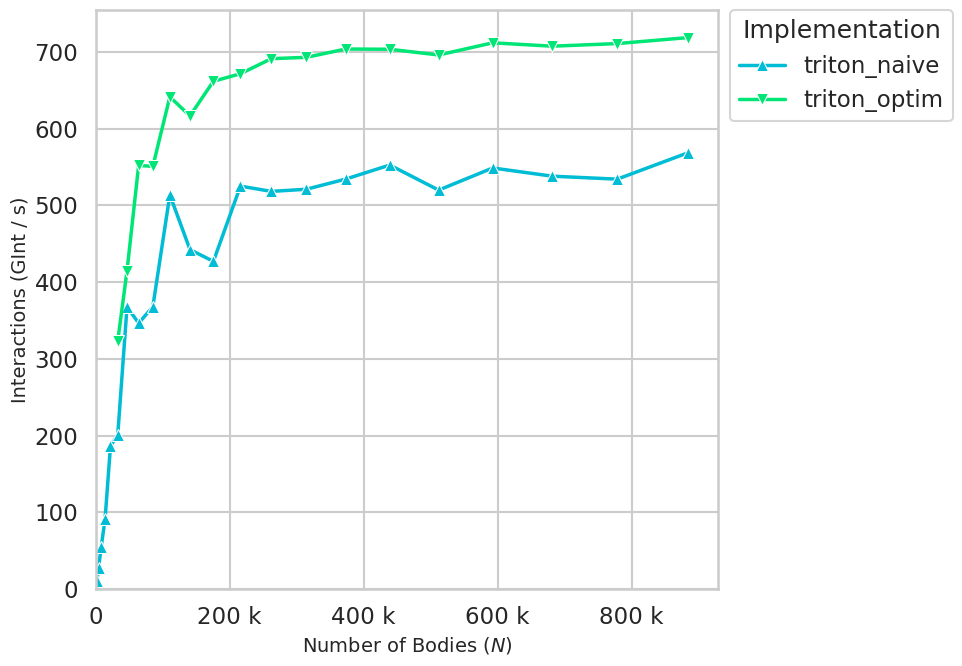

In [22]:
target_files = [
    'benchmark_triton_naive.json',
    'benchmark_triton_optim.json',
]

plot_linear(target_files)

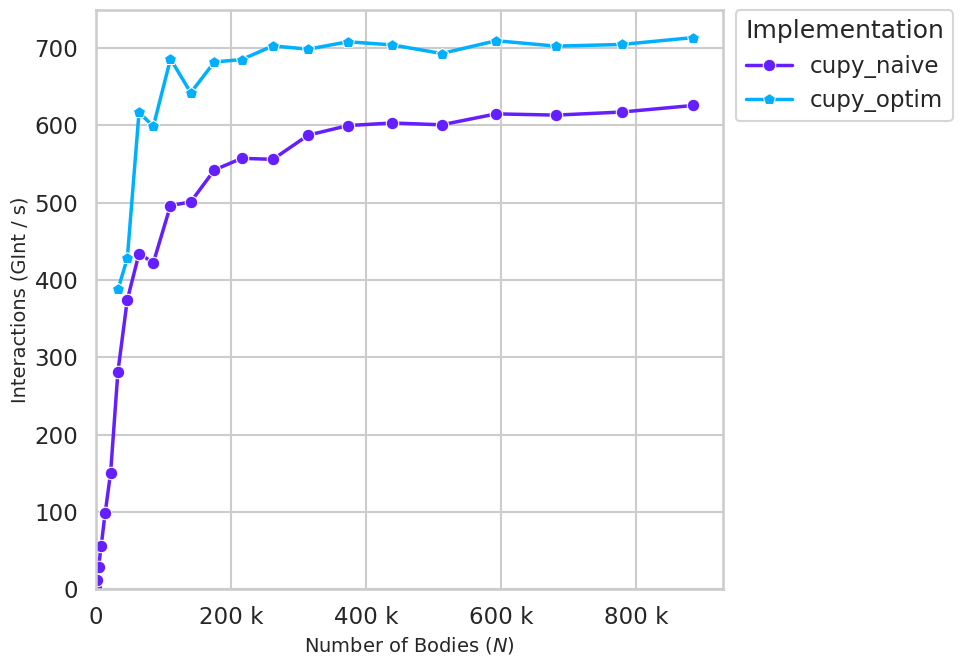

In [23]:
target_files = [
    'benchmark_cupy_naive.json',
    'benchmark_cupy_optim.json',
]

plot_linear(target_files)

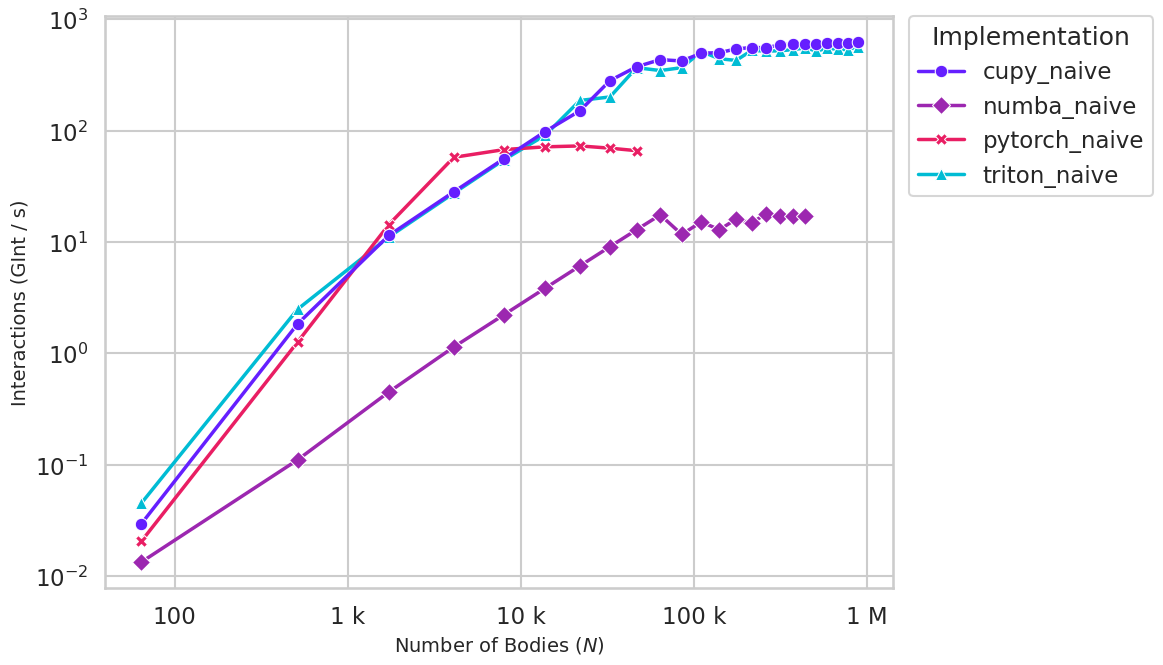

In [19]:
target_files = [
    'benchmark_numba_naive.json',
    'benchmark_triton_naive.json',
    'benchmark_pytorch_naive.json',
    'benchmark_cupy_naive.json',
]

plot_log(target_files)

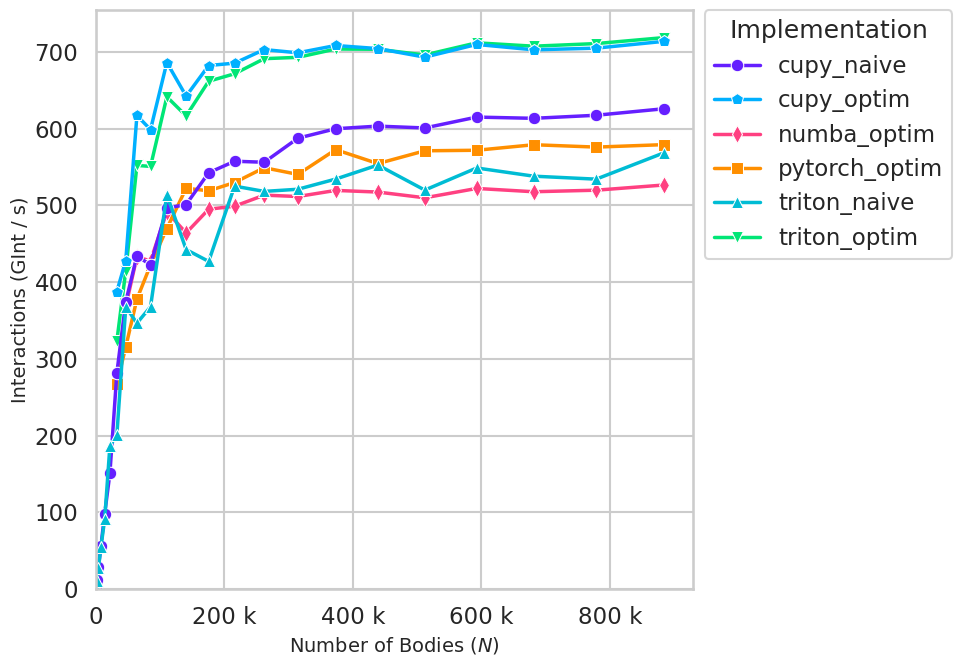

In [24]:
target_files = [
    'benchmark_numba_optim.json',
    'benchmark_triton_optim.json',
    'benchmark_pytorch_optim.json',
    'benchmark_cupy_optim.json',
    'benchmark_cupy_naive.json',
    'benchmark_triton_naive.json',
]

plot_linear(target_files)

In [27]:
import json
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker


def plot_performance(target_files, scale='linear', save_path=None):
    param_palette = {
        '32': '#00B0FF',   # Electric Blue
        '64': '#00E676',   # Spring Green
        '128': '#FF4081',  # Hot Pink
        '256': '#FF9100',  # Neon Orange
    }

    framework_markers = {
        'cupy': 'o',       # Circle
        'triton': 's',     # Square
        'numba': '^',      # Triangle
    }

    base_path = 'results/scaling_reports_var'
    data_list = []

    # 3. Load and parse the data
    for fname in target_files:
        full_path = os.path.join(base_path, fname)
        
        if not os.path.exists(full_path):
            print(f"Warning: File not found -> {full_path}")
            continue
            
        with open(full_path, 'r') as f:
            content = json.load(f)
        
        # Parse framework and parameter directly from the filename
        name_parts = fname.replace('.json', '').split('_')
        if len(name_parts) >= 3:
            framework = name_parts[1]
            param_val = name_parts[2]
        else:
            print(f"Warning: Unrecognized filename format -> {fname}")
            continue
            
        # Extract data
        num_bodies = content['data']['num_bodies']
        giga_int_per_sec = [x / 1e9 for x in content['data']['interactions_per_second']]
        
        for n, i in zip(num_bodies, giga_int_per_sec):
            data_list.append({
                'N': n,
                'GInt/s': i,
                'Framework': framework,
                'Block Size / Threads': param_val  # <-- UPDATED COLUMN NAME
            })

    # 4. Create DataFrame
    df = pd.DataFrame(data_list)

    if df.empty:
        print("No data loaded. Please check your filenames and folder paths.")
        return

    # 5. Setup Plot
    sns.set_theme(style="whitegrid", context="talk")
    plt.figure(figsize=(12, 8))

    # Sort the dataframe so the legend renders in numerical order
    df['Block Size / Threads'] = pd.Categorical(
        df['Block Size / Threads'], 
        categories=['32', '64', '128', '256'], 
        ordered=True
    )
    df = df.sort_values(['Block Size / Threads', 'Framework'])

    # 6. Plot
    ax = sns.lineplot(
        data=df,
        x='N',
        y='GInt/s',
        hue='Block Size / Threads',  # <-- Matches the new column name
        style='Framework',     
        palette=param_palette,       
        markers=framework_markers, 
        dashes=False, 
        linewidth=2.5,
        markersize=9
    )

    # 7. Configure Axes based on scale parameter
    if scale == 'log':
        plt.xscale('log')
        plt.yscale('log')
        title_suffix = '(Log Scale)'
    else:
        plt.xscale('linear')
        plt.yscale('linear')
        plt.xlim(left=0)
        plt.ylim(bottom=0)
        title_suffix = '(Linear Scale)'

    # Format X-axis with readable Engineering notation
    ax.xaxis.set_major_formatter(ticker.EngFormatter())

    # Labels
    # plt.title(f'Performance Scaling by Block Size / Threads', fontsize=18, pad=20)
    plt.xlabel('Number of Bodies ($N$)', fontsize=14)
    plt.ylabel('Interactions (GInt / s)', fontsize=14)
    
    # Legend formatting
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)

    plt.tight_layout()
    
    # Save if a path is provided
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Plot saved to {save_path}")
        
    plt.show()



Plot saved to scaling_linear.png


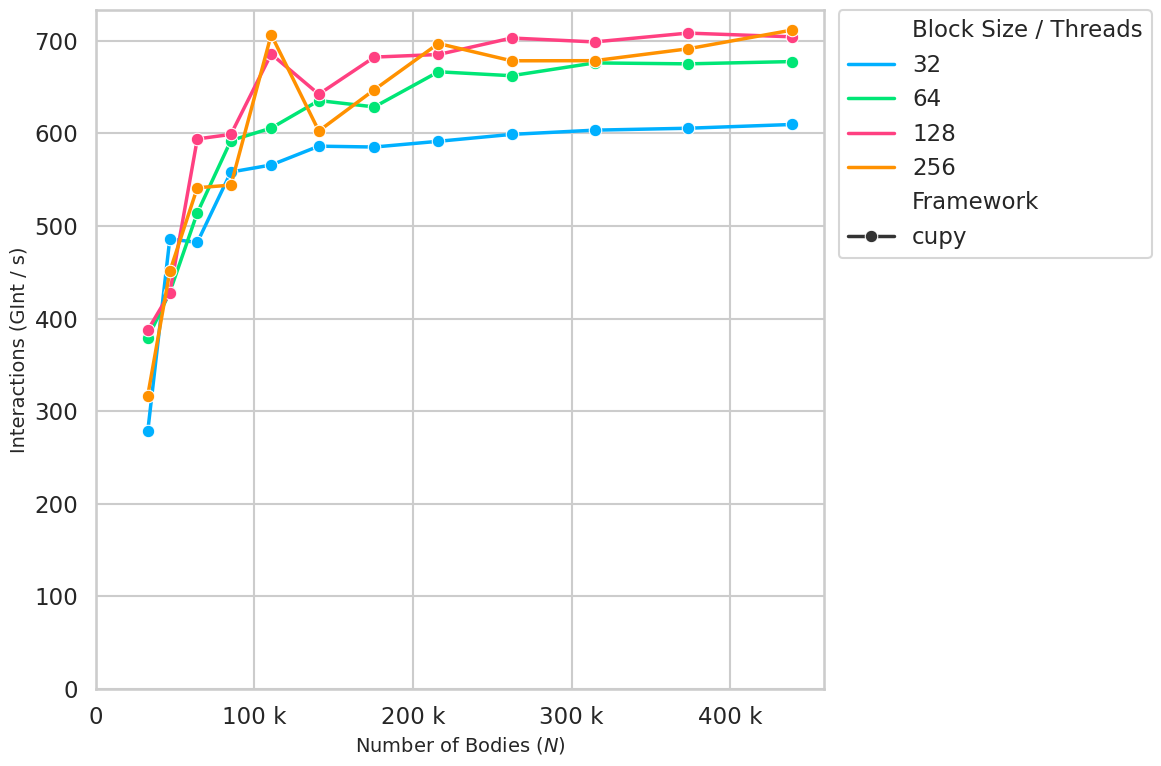

In [28]:
target_files = [
    'benchmark_cupy_32.json',
    'benchmark_cupy_64.json',
    'benchmark_cupy_128.json',
    'benchmark_cupy_256.json',
]

plot_performance(target_files, scale='linear', save_path='scaling_linear.png')


Plot saved to scaling_linear.png


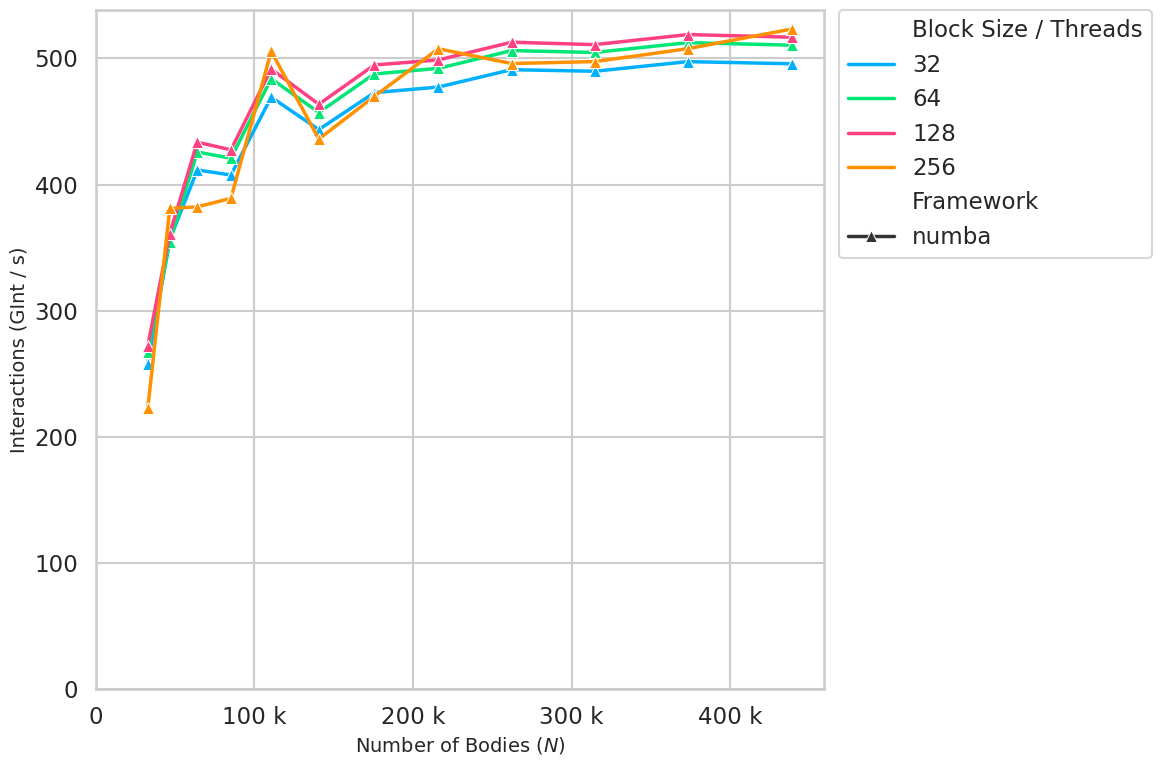

In [25]:
target_files = [
    'benchmark_numba_32.json',
    'benchmark_numba_64.json',
    'benchmark_numba_128.json',
    'benchmark_numba_256.json',
]

plot_performance(target_files, scale='linear', save_path='scaling_linear.png')


Plot saved to scaling_linear.png


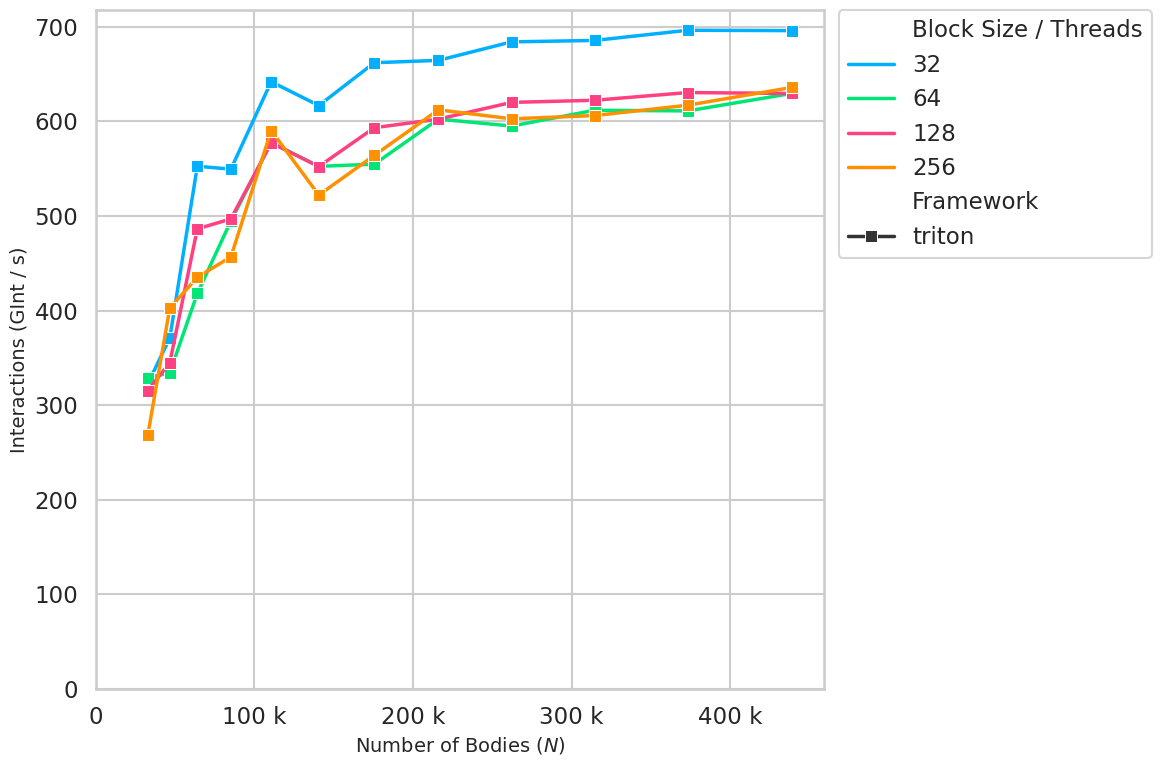

In [26]:
target_files = [
    'benchmark_triton_32.json',
    'benchmark_triton_64.json',
    'benchmark_triton_128.json',
    'benchmark_triton_256.json',
]

plot_performance(target_files, scale='linear', save_path='scaling_linear.png')
